# `ANFISpy` tutorial

Here, we are going to give a brief tutorial about the `ANFIS` model usage.

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import sys
import os

diretorio_atual = os.getcwd()

diretorio_pai = os.path.abspath(os.path.join(diretorio_atual, '..'))

if diretorio_pai not in sys.path:
    sys.path.append(diretorio_pai)


from ANFISpy import ANFIS
from ANFISpy import ProdAND

## Classification

Now, we are going to perform a classification problem.

In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Loading the dataset:

In [3]:
SEED = 10
torch.manual_seed = SEED

df = pd.read_csv('lr_mc_CPU_Storage_Mem_BW_MIPS_Energy.csv')
df = df.dropna()

FEATURES = ['CPU', 'Storage', 'Mem', 'BW', 'MIPS', 'Energy']
TARGET = ['Class']

print(FEATURES)
print(TARGET)

x = df[FEATURES].values
y = df[TARGET].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y.ravel())

print(x)
print(x.shape)
print(y)
print(y.shape)

['CPU', 'Storage', 'Mem', 'BW', 'MIPS', 'Energy']
['Class']
[[0.09402194 0.00250627 0.00663757 0.1        0.27654867 0.        ]
 [0.09402194 0.01010101 0.03786469 0.1        0.66371681 0.        ]
 [0.09402194 0.00502513 0.01991272 0.1        0.49778761 0.        ]
 ...
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]]
(16278, 6)
[0 0 0 ... 0 0 0]
(16278,)


Train, test and validation split:

In [4]:
x, index = np.unique(x, axis=0, return_index=True)
y = y[index]

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=SEED)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=SEED)

x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

x_train_max = x_train.max(dim=0, keepdim=True)[0]
x_test_max = x_test.max(dim=0, keepdim=True)[0]
x_val_max = x_val.max(dim=0, keepdim=True)[0]

x_train /= x_train_max
x_test /= x_test_max
x_val /= x_val_max

Creating the DataLoaders:

In [5]:
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Instantiating the model:

In [32]:
n_vars = len(x[0])
mf_names = [['L', 'M', 'H']]

variables = {
    'inputs': {
        'n_sets': n_vars * [3],
        'uod': n_vars * [(0, 1)],
        'var_names': FEATURES,
        'mf_names': n_vars * mf_names,
    },
    'output': {
        'var_names': label_encoder.classes_,
        'n_classes': len(label_encoder.classes_),
    },
}

from ANFISpy import aggregators
from ANFISpy import layer5
anfis = ANFIS(
    variables=variables, 
    mf_shape= 'gaussian',
    and_operator= aggregators.ProdAND,
    layer_5_aggregator=layer5.WeightedSumANFISLayer5,
    )

Defining the loss and the optimizer:

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(anfis.parameters(), lr=0.001)

Training the model:

In [35]:
import time
import datetime

inicio = time.time()

epochs = 500
train_losses, val_losses = [], []

for epoch in range(epochs):
    anfis.train()
    train_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = anfis(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    anfis.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_pred = anfis(x_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    if epoch % 10 == 9:
        print(f'Epoch {epoch+1}/{epochs}: train_loss: {train_loss:.4f} validation_loss {val_loss:.4f}')
print(f"Treinamento concluído em: {(time.time() - inicio):.4f} segundos")
tempo_formatado = str(datetime.timedelta(seconds=round((time.time() - inicio))))
print(f"Tempo de execução: {tempo_formatado} (H:MM:SS)")

TypeError: ProdAND.__init__() got an unexpected keyword argument 'dim'

Evaluating the performance:

In [ ]:
with torch.no_grad():
    y_pred = anfis(x_test)
    y_pred = torch.argmax(y_pred, dim=1)  
    accuracy = accuracy_score(y_test.numpy(), y_pred.numpy())  
    print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9851


Plotting the confusion matrix:

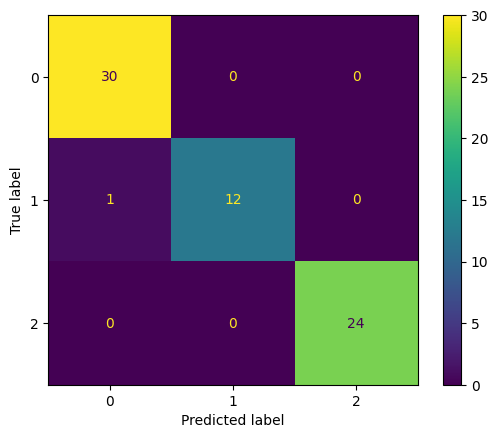

In [ ]:
true_labels = y_test.numpy()
predicted_labels = y_pred.numpy()

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.show()

Printing the rules:

In [ ]:
rules = anfis.print_rules(precision=3)
rules

["Rule 0 (['Adelie' 'Chinstrap' 'Gentoo']): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L AND body_mass_g IS L, THEN f0_0 = (-0.183 * bill_length_mm) + (-0.347 * bill_depth_mm) + (-0.102 * flipper_length_mm) + (-0.062 * body_mass_g) + 0.480",
 "Rule 0 (['Adelie' 'Chinstrap' 'Gentoo']): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L AND body_mass_g IS L, THEN f0_1 = (-0.427 * bill_length_mm) + (-0.337 * bill_depth_mm) + (0.167 * flipper_length_mm) + (0.376 * body_mass_g) + 0.096",
 "Rule 0 (['Adelie' 'Chinstrap' 'Gentoo']): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L AND body_mass_g IS L, THEN f0_2 = (-0.332 * bill_length_mm) + (-0.436 * bill_depth_mm) + (-0.529 * flipper_length_mm) + (-0.272 * body_mass_g) + 0.273",
 "Rule 1 (['Adelie' 'Chinstrap' 'Gentoo']): IF bill_length_mm IS L AND bill_depth_mm IS L AND flipper_length_mm IS L AND body_mass_g IS M, THEN f1_0 = (0.544 * bill_length_mm) + (-0.279 * bill